# New Dataset Preparation - Expanded

### Packages

In [1]:
# Basic Package Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score
from sklearn.metrics import mean_squared_error, r2_score

# imblearn
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# Non-basic package imports
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import requests

# Packages I don't understand
from fcd_torch import FCD
import rdkit
from collections import Counter
import gc
import pickle

# Add the Python_files directory to the Python path
import sys
import os
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'Python_files'))

# Now you can import your modules
# import functions_enc as f
import function_depot as fd

# Data Processing

### DF5 Upload

GROUP STATISTICS 
Group                     Total Spectra   Unique SMILES  
LTQ-Orbitrap-negative     121             23             
LTQ-Orbitrap-positive     615             70             
LTQ-negative              13              10             
LTQ-positive              12              2              
Other-negative            12              8              
Other-positive            79              25             
Q-Orbitrap-negative       1400            252            
Q-Orbitrap-positive       2065            378            
Q-TOF-negative            235             56             
Q-TOF-positive            1098            221            
QQQ-negative              162             34             
QQQ-positive              286             85             

Total across all groups: 6098            678      

The code that produced this

Print group statistics for unique SMILES and spectra counts
print("=== GROUP STATISTICS ===")
print(f"{'Group':<25} {'Total Spectra':<15} {'Unique SMILES':<15}")
print("-" * 55)

for group in sorted(df5['Group'].unique()):
    group_data = df5[df5['Group'] == group]
    total_spectra = len(group_data)
    unique_smiles = group_data['SMILES_spectra'].nunique()
    
    print(f"{group:<25} {total_spectra:<15} {unique_smiles:<15}")

print(f"\nTotal across all groups: {len(df5):<15} {df5['SMILES_spectra'].nunique():<15}")

Groups included: ['Q-Orbitrap-positive' 'Q-TOF-positive' 'LTQ-Orbitrap-positive']
Unique SMILES: 485

In [2]:
# We are working with the June 25 dataset, with the Morgan Fingerprints and cannonical SMILES included
df5 = pd.read_csv("/home/dlipsey/MITLincolnLabs/MIT_LL_data/MIT_LL_data5.csv")
# print(df5.shape)
# df5.head()

# First order of business is to standardize our SMILES column. We want to use canonical smiles rather than SMILES_spectra but 
# we will keep the column name SMILES_spectra for consistency with previous code
df5 = df5.drop('SMILES_spectra', axis=1) # Drop
df5 = df5.rename(columns={'canonical_smiles': 'SMILES_spectra'}) # Rename
cols = df5.columns.tolist()
cols.remove('SMILES_spectra') 
df5 = df5[['SMILES_spectra'] + cols] # Move to front

# Next we want to standardize the Ionization column
# print(df5["Ionization_Mode"].unique()) # Check unique values
df5["Ionization_Mode"] = df5["Ionization_Mode"].replace("'Positive'", "'positive'") # Fix capitaliztion
df5 = df5[df5["Ionization_Mode"] != "'N/A'"] # Remove N/A 
# print(df5["Ionization_Mode"].unique()) # Check unique values

# Remove single quotes from all columns
df5 = df5.applymap(lambda x: x.replace("'", "") if isinstance(x, str) else x)

# Select specific groups for subset
selected_groups = ['Q-Orbitrap-positive', 'Q-TOF-positive', 'LTQ-Orbitrap-positive']

# Create subset with only selected groups
df5_subset = df5[df5['Group'].isin(selected_groups)]

print(df5_subset.shape)
df5_subset.head()

(3778, 18)


,SMILES_spectra,CAS,Molecular_Formula,Total_Exact_Mass,Precursor_m/z,Precursor_Type,Spectrum,Ionization_Mode,Instrument_Type,Instrument_Name,Collision_Energy,SMILES_tox_vals,Response_Modifier,Response,Response_Unit,Group,fp,filtered_fp
0,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,63.0228:0.177223 65.0386:5.629055 68.0495:0.45...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,90 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,63.0228:0.125979 65.0386:2.113734 68.0495:0.68...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,75 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,56.0496:0.115017 65.0386:0.970445 68.0495:1.03...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,60 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,51.0229:0.102992 56.0495:0.143820 65.0386:0.67...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,45 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,C#CCN(C)Cc1ccccc1,555-57-7,C11H13N,159.104799416,160.1121,[M+H]+,56.0496:0.482623 65.0385:0.377829 68.0495:2.59...,positive,LC-ESI-QFT,Q Exactive Orbitrap Thermo Scientific,30 (nominal),C#CCN(C)Cc1ccccc1,,273.642508,mg/kg,Q-Orbitrap-positive,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


### Dataframe Creation - Added to MIT_LL_data directory

In [3]:
# DF5 SUBSET DATAFRAME
# df5_subset.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_subset.parquet', index=False)


# # # Save the dataframes to data folder as parquet files
# # df5_spectra.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_spectra.parquet', index=False)
# df5_chemnet.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_chemnet.parquet', index=False)
# # df5_morganfp.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_morganfp.parquet', index=False)


In [4]:
# SPECTRA DATAFRAME
# Create dataframe with spectra using spectrum_string_to_dataframe
df5_spectra = fd.spectrum_string_to_dataframe(df5_subset, spectrum_col='Spectrum', smiles_col='SMILES_spectra')

# Add Group and Response columns by mapping directly from df5_subset
# Create dictionaries for faster lookup
smiles_to_group = df5_subset.set_index('SMILES_spectra')['Group'].to_dict()
smiles_to_response = df5_subset.set_index('SMILES_spectra')['Response'].to_dict()

# Map the values directly
df5_spectra['Group'] = df5_spectra['SMILES_spectra'].map(smiles_to_group)
df5_spectra['Response'] = df5_spectra['SMILES_spectra'].map(smiles_to_response)

# Remove columns with m/z values greater than 900
columns_to_keep = []
for col in df5_spectra.columns:
    # Keep non-numeric columns (SMILES_spectra, Group, Response)
    if col in ['SMILES_spectra', 'Group', 'Response', 'index_id']:
        columns_to_keep.append(col)
    else:
        try:
            # Check if column name can be converted to float and is <= 900
            mz_value = float(col)
            if mz_value <= 900:
                columns_to_keep.append(col)
        except (ValueError, TypeError):
            # Keep columns that can't be converted to float (non-m/z columns)
            columns_to_keep.append(col)

# Filter the dataframe to only keep desired columns
df5_spectra = df5_spectra[columns_to_keep]

print("=== SPECTRA DATAFRAME (FILTERED) ===")
print(f"Shape: {df5_spectra.shape}")
print(f"Unique SMILES: {df5_spectra['SMILES_spectra'].nunique()}")
print(f"Columns: {list(df5_spectra.columns[:3])} ... {list(df5_spectra.columns[-3:])}")  # Show first and last few columns

# Optional: Print how many m/z columns were removed
original_cols = len([col for col in df5_spectra.columns if col not in ['SMILES_spectra', 'Group', 'Response']])
removed_cols = len([col for col in df5_spectra.columns if col not in ['SMILES_spectra', 'Group', 'Response']]) 
print(f"Kept m/z columns <= 900. Remaining spectral features: {len(columns_to_keep) - 3}")
df5_spectra.head()

=== SPECTRA DATAFRAME (FILTERED) ===
Shape: (3778, 64106)
Unique SMILES: 485
Columns: ['SMILES_spectra', 29.0112, 30.032] ... ['index_id', 'Group', 'Response']
Kept m/z columns <= 900. Remaining spectral features: 64103


,SMILES_spectra,29.0112,30.032,30.0323,31.01686,31.54035,38.5076,39.0214,39.0215,39.02194,...,883.572754,884.950439,886.320984,889.633972,893.959961,895.855774,898.654114,index_id,Group,Response
0,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,Q-Orbitrap-positive,273.642508
1,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,Q-Orbitrap-positive,273.642508
2,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,Q-Orbitrap-positive,273.642508
3,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,Q-Orbitrap-positive,273.642508
4,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,Q-Orbitrap-positive,273.642508


In [5]:
# # CHEMNET EMBEDDINGS
# # Create ChemNet embeddings dataframe using get_chemnet_emb_from_smiles
# unique_smiles = df5_subset['SMILES_spectra'].unique().tolist()
# print(f"Getting ChemNet embeddings for {len(unique_smiles)} unique SMILES...")

# # Get embeddings dictionary
# embeddings_dict = fd.get_chemnet_emb_from_smiles(unique_smiles)

# # Convert to dataframe format
# embeddings_data = []
# for smiles, embedding in embeddings_dict.items():
#     if embedding != 'unknown':  # Skip unknown embeddings
#         row = {'SMILES_spectra': smiles}
#         # Add each embedding dimension as a separate column
#         for i, emb_val in enumerate(embedding):
#             row[f'Embedding Float {i}'] = emb_val
#         embeddings_data.append(row)

# df5_chemnet = pd.DataFrame(embeddings_data)

# print("\n=== EMBEDDINGS DATAFRAME ===")
# print(f"Shape: {df5_chemnet.shape}")
# print(f"Unique SMILES: {df5_chemnet['SMILES_spectra'].nunique()}")
# print(f"Embedding dimensions: {df5_chemnet.shape[1] - 1}")  # -1 for SMILES column
# df5_chemnet.head()

In [6]:
# # MORGAN FINGERPRINTS
# # Create dataframe with just SMILES and Morgan fingerprints using expand_fingerprints_to_matrix
# df5_morganfp= fd.expand_fingerprints_to_matrix(df5_subset, smiles_col='SMILES_spectra', fp_col='fp')

# print("\n=== FINGERPRINTS DATAFRAME ===")
# print(f"Shape: {df5_morganfp.shape}")
# print(f"Unique SMILES: {df5_morganfp['SMILES_spectra'].nunique()}")
# df5_morganfp.head()

In [7]:
# # Save the datafames to data folder
# df5_spectra = df5_spectra.to_csv('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_spectra.csv', index=False)
# df5_chemnet = df5_chemnet.to_csv('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_chemnet.csv', index=False)
# df5_morganfp = df5_morganfp.to_csv('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_morganfp.csv', index=False)

# # Load dataframes into notebook - Beware, these can take a while to load
# df5_spectra = pd.read_csv('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_spectra.csv')
# df5_chemnet = pd.read_csv('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_chemnet.csv')
# df5_morganfp = pd.read_csv('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_morganfp.csv')


# Binning

In [8]:
# df = pd.read_pickle('/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes/bin0_1_thresh0_1_df_spectra.pkl')
# df = pd.read_pickle('/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes/bin0_1_thresh100_df_spectra.pkl')
# df = pd.read_pickle('/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes/bin0_05_thresh0_1_df_spectra.pkl')
# df = pd.read_pickle('/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes/bin0_05_thresh100_df_spectra.pkl')
# df = pd.read_pickle('/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes/bin500_thresh50_df_spectra.pkl')
# df.head()

In [9]:
# Define your parameters
bin_sizes = [0.05, 0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]
thresholds = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
save_directory = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes"

# Create all datasets
# all_datasets = fd.binning_loop(df5_spectra, df5_subset, bin_sizes, thresholds, save_directory, indx_id_indx=-3, startindx=1, stopindx=-3)

In [10]:
# DF5 SUBSET DATAFRAME
# df5_subset.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_subset.parquet', index=False)


# # # Save the dataframes to data folder as parquet files
# df5_spectra.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_spectra.parquet', index=False)
# df5_chemnet.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_chemnet.parquet', index=False)
# df5_morganfp.to_parquet('/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_morganfp.parquet', index=False)


# Spectra RF and Heatmap

Processing single dataset: bin0_1_thresh0_1_df_spectra
Loaded dataset shape: (3778, 11618)
Columns: ['SMILES_spectra', 0.05, 0.15000000000000002, 0.25, 0.35, 0.44999999999999996, 0.5499999999999999, 0.6499999999999999, 0.7499999999999999, 0.8499999999999999, 0.9499999999999998, 1.0499999999999998, 1.15, 1.25, 1.35, 1.4500000000000002, 1.5500000000000003, 1.6500000000000004, 1.7500000000000004, 1.8500000000000005, 1.9500000000000006, 2.0500000000000007, 2.150000000000001, 2.250000000000001, 2.350000000000001, 2.450000000000001, 2.550000000000001, 2.6500000000000012, 2.7500000000000013, 2.8500000000000014, 2.9500000000000015, 3.0500000000000016, 3.1500000000000017, 3.2500000000000018, 3.350000000000002, 3.450000000000002, 3.550000000000002, 3.650000000000002, 3.750000000000002, 3.8500000000000023, 3.9500000000000024, 4.0500000000000025, 4.150000000000002, 4.250000000000002, 4.350000000000001, 4.450000000000001, 4.550000000000001, 4.65, 4.75, 4.85, 4.949999999999999, 5.049999999999999, 5.

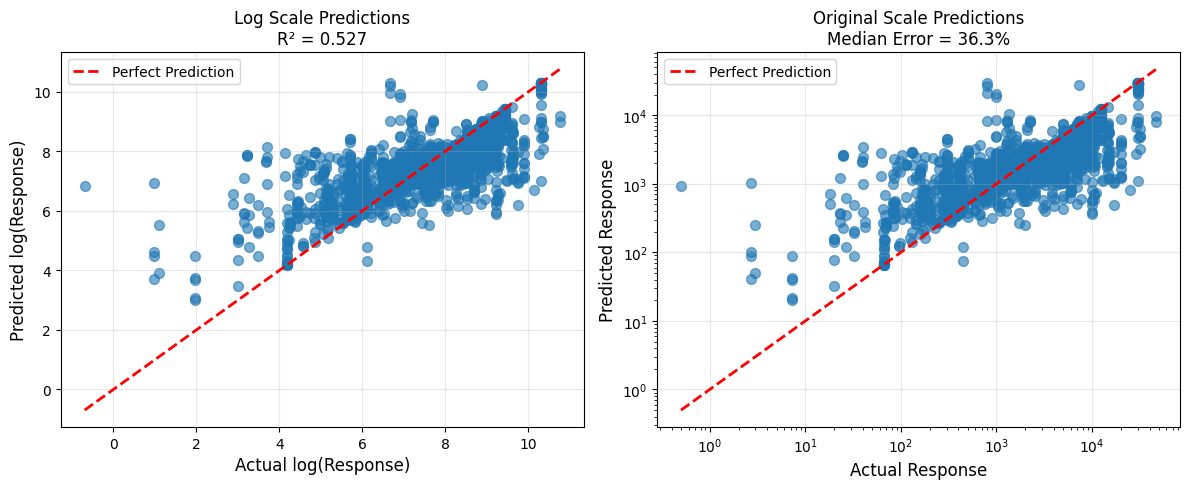

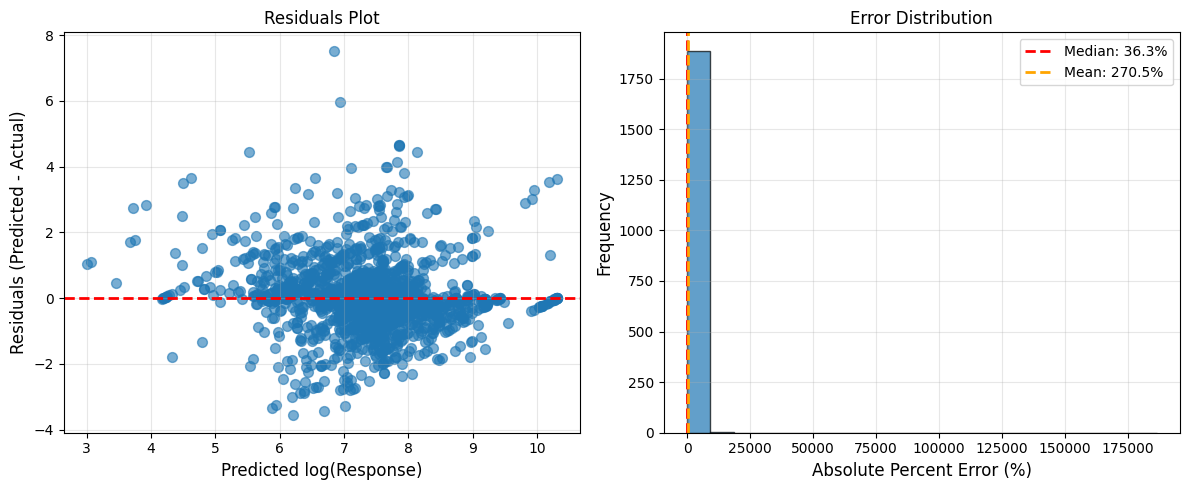


Analysis complete for bin0_1_thresh0_1_df_spectra


In [11]:
# Load and analyze a single dataset
dataset_name = "bin0_1_thresh0_1_df_spectra"  # Change this to your desired dataset
grid_search_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes"

print(f"Processing single dataset: {dataset_name}")

try:
    # Load the single dataset
    file_path = os.path.join(grid_search_folder, f"{dataset_name}.pkl")
    df = pd.read_pickle(file_path)
    
    print(f"Loaded dataset shape: {df.shape}")
    print(f"Columns: {list(df.columns)}")
    
    # Prepare features and target
    feature_cols = [col for col in df.columns if col not in ['SMILES_spectra', 'Response', 'log_response', 'index_id']]
    X = df[feature_cols]
    y = df['log_response']
    
    print(f"Feature columns ({len(feature_cols)}): {feature_cols[:5]}...")  # Show first 5 feature columns
    
    # Remove rows with NaN values
    valid_mask = ~(X.isna().any(axis=1) | y.isna())
    X_clean = X[valid_mask]
    y_clean = y[valid_mask]
    
    print(f"Clean data shape: X={X_clean.shape}, y={y_clean.shape}")
    
    if len(X_clean) < 10:
        print(f"Error: Only {len(X_clean)} valid samples - need at least 10")
    else:
        # Split the data
        X_train, X_test, y_train, y_test = train_test_split(
            X_clean, y_clean, test_size=0.5, random_state=42
        )
        
        print(f"Train/Test split: {X_train.shape[0]} / {X_test.shape[0]} samples")
        
        # Train Random Forest
        rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=2)
        rf.fit(X_train, y_train)
        
        # Make predictions
        y_train_pred = rf.predict(X_train)
        y_test_pred = rf.predict(X_test)
        
        # Calculate R² metrics
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        # Calculate absolute percent error (undo log transform first)
        y_train_true_response = np.exp(y_train)
        y_train_pred_response = np.exp(y_train_pred)
        y_test_true_response = np.exp(y_test)
        y_test_pred_response = np.exp(y_test_pred)
        
        # Calculate individual errors for test set
        individual_errors = np.abs((y_test_pred_response - y_test_true_response) / y_test_true_response) * 100
        
        # Calculate median and mean absolute percent error
        train_median_percent_error = 100 * (np.median(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        test_median_percent_error = 100 * (np.median(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))
        train_mean_percent_error = 100 * (np.mean(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        test_mean_percent_error = 100 * (np.mean(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))

        # Print results
        print(f"\n=== RESULTS FOR {dataset_name} ===")
        print(f"Train R²: {train_r2:.4f}")
        print(f"Test R²: {test_r2:.4f}")
        print(f"Train Median % Error: {train_median_percent_error:.1f}%")
        print(f"Test Median % Error: {test_median_percent_error:.1f}%")
        print(f"Train Mean % Error: {train_mean_percent_error:.1f}%")
        print(f"Test Mean % Error: {test_mean_percent_error:.1f}%")
        print(f"Number of samples: {len(X_clean)}")
        print(f"Number of features: {len(feature_cols)}")
        
        # Store in single result dictionary
        single_result = {
            'Dataset': dataset_name,
            'Train_R2': train_r2,
            'Test_R2': test_r2,
            'Train_Median_Percent_Error': train_median_percent_error,
            'Test_Median_Percent_Error': test_median_percent_error,
            'Train_Mean_Percent_Error': train_mean_percent_error,
            'Test_Mean_Percent_Error': test_mean_percent_error,
            'Samples': len(X_clean),
            'Features': len(feature_cols),
            'Individual_Errors': individual_errors
        }
        # === ACCURACY ILLUSTRATION PLOTS ===
        
        # 1. Predicted vs Actual scatter plot (log scale)
        plt.figure(figsize=(12, 5))
        
        # Left subplot: Log-transformed values
        plt.subplot(1, 2, 1)
        plt.scatter(y_test, y_test_pred, alpha=0.6, s=50)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
        plt.xlabel('Actual log(Response)', fontsize=12)
        plt.ylabel('Predicted log(Response)', fontsize=12)
        plt.title(f'Log Scale Predictions\nR² = {test_r2:.3f}', fontsize=12)
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        # Right subplot: Original scale (undoing log transform)
        plt.subplot(1, 2, 2)
        plt.scatter(y_test_true_response, y_test_pred_response, alpha=0.6, s=50)
        plt.plot([y_test_true_response.min(), y_test_true_response.max()], 
                 [y_test_true_response.min(), y_test_true_response.max()], 'r--', lw=2, label='Perfect Prediction')
        plt.xlabel('Actual Response', fontsize=12)
        plt.ylabel('Predicted Response', fontsize=12)
        plt.title(f'Original Scale Predictions\nMedian Error = {test_median_percent_error:.1f}%', fontsize=12)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.xscale('log')
        plt.yscale('log')
        
        plt.tight_layout()
        plt.savefig(f"/home/dlipsey/MITLincolnLabs/Figures/RF_Accuracy_{dataset_name}.png", dpi=300, bbox_inches='tight')
        plt.show()
        
        # 2. Residuals and error distribution plot
        plt.figure(figsize=(12, 5))
        
        # Left subplot: Residuals plot
        plt.subplot(1, 2, 1)
        residuals = y_test_pred - y_test
        plt.scatter(y_test_pred, residuals, alpha=0.6, s=50)
        plt.axhline(y=0, color='r', linestyle='--', lw=2)
        plt.xlabel('Predicted log(Response)', fontsize=12)
        plt.ylabel('Residuals (Predicted - Actual)', fontsize=12)
        plt.title('Residuals Plot', fontsize=12)
        plt.grid(True, alpha=0.3)
        
        # Right subplot: Error distribution histogram
        plt.subplot(1, 2, 2)
        plt.hist(individual_errors, bins=20, alpha=0.7, edgecolor='black')
        plt.axvline(test_median_percent_error, color='red', linestyle='--', linewidth=2, 
                   label=f'Median: {test_median_percent_error:.1f}%')
        plt.axvline(test_mean_percent_error, color='orange', linestyle='--', linewidth=2, 
                   label=f'Mean: {test_mean_percent_error:.1f}%')
        plt.xlabel('Absolute Percent Error (%)', fontsize=12)
        plt.ylabel('Frequency', fontsize=12)
        plt.title('Error Distribution', fontsize=12)
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f"/home/dlipsey/MITLincolnLabs/Figures/RF_ErrorAnalysis_{dataset_name}.png", dpi=300, bbox_inches='tight')
        plt.show()
        print(f"\nAnalysis complete for {dataset_name}")
        
except Exception as e:
    print(f"Error processing {dataset_name}: {str(e)}")
    import traceback
    traceback.print_exc()

Processing dataset with different training set sizes: bin0_1_thresh0_1_df_spectra
Loaded dataset shape: (3778, 11618)
Clean data shape: X=(3778, 11616), y=(3778,)

--- Training with 80% / 20% split ---
Train/Test split: 3022 / 756 samples
Train R²: 0.9422, Test R²: 0.6352
Train Median Error: 12.4%, Test Median Error: 29.4%
Train Mean Error: 26.0%, Test Mean Error: 144.9%

--- Training with 60% / 40% split ---
Train/Test split: 2266 / 1512 samples
Train R²: 0.9423, Test R²: 0.5424
Train Median Error: 13.7%, Test Median Error: 34.9%
Train Mean Error: 26.1%, Test Mean Error: 293.2%

--- Training with 40% / 60% split ---
Train/Test split: 1511 / 2267 samples
Train R²: 0.9352, Test R²: 0.4708
Train Median Error: 15.5%, Test Median Error: 39.5%
Train Mean Error: 29.0%, Test Mean Error: 259.1%

--- Training with 20% / 80% split ---
Train/Test split: 755 / 3023 samples
Train R²: 0.9083, Test R²: 0.3924
Train Median Error: 21.1%, Test Median Error: 51.0%
Train Mean Error: 39.2%, Test Mean Error

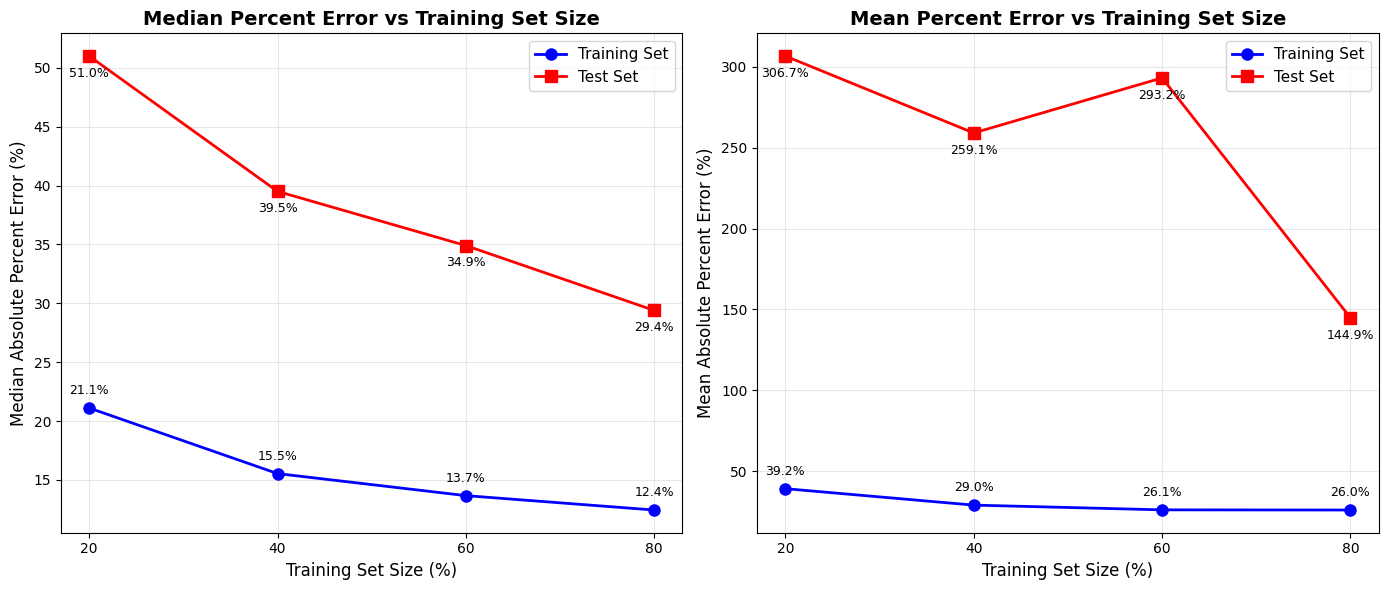


=== SUMMARY TABLE ===
Train%   Test%    Train Samples Test Samples Test R²  Test Median% Test Mean%
--------------------------------------------------------------------------------
   80%      20%        3022.0          756.0      0.635         29.4%       144.9%
   60%      40%        2266.0         1512.0      0.542         34.9%       293.2%
   40%      60%        1511.0         2267.0      0.471         39.5%       259.1%
   20%      80%         755.0         3023.0      0.392         51.0%       306.7%

Analysis complete for bin0_1_thresh0_1_df_spectra


In [12]:
# Loop through different training set sizes and analyze performance
dataset_name = "bin0_1_thresh0_1_df_spectra"
grid_search_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes"

print(f"Processing dataset with different training set sizes: {dataset_name}")

# Define training set sizes to test
train_sizes = [0.8, 0.6, 0.4, 0.2]
results_summary = []

try:
    # Load the dataset once
    file_path = os.path.join(grid_search_folder, f"{dataset_name}.pkl")
    df = pd.read_pickle(file_path)
    
    print(f"Loaded dataset shape: {df.shape}")
    
    # Prepare features and target
    feature_cols = [col for col in df.columns if col not in ['SMILES_spectra', 'Response', 'log_response', 'index_id']]
    X = df[feature_cols]
    y = df['log_response']
    
    # Remove rows with NaN values
    valid_mask = ~(X.isna().any(axis=1) | y.isna())
    X_clean = X[valid_mask]
    y_clean = y[valid_mask]
    
    print(f"Clean data shape: X={X_clean.shape}, y={y_clean.shape}")
    
    # Loop through different training set sizes
    for train_size in train_sizes:
        test_size = 1 - train_size
        print(f"\n--- Training with {train_size*100:.0f}% / {test_size*100:.0f}% split ---")
        
        # Split the data
        X_train, X_test, y_train, y_test = train_test_split(
            X_clean, y_clean, test_size=test_size, random_state=42
        )
        
        print(f"Train/Test split: {X_train.shape[0]} / {X_test.shape[0]} samples")
        
        # Train Random Forest
        rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=2)
        rf.fit(X_train, y_train)
        
        # Make predictions
        y_train_pred = rf.predict(X_train)
        y_test_pred = rf.predict(X_test)
        
        # Calculate R² metrics
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        # Calculate absolute percent error (undo log transform first)
        y_train_true_response = np.exp(y_train)
        y_train_pred_response = np.exp(y_train_pred)
        y_test_true_response = np.exp(y_test)
        y_test_pred_response = np.exp(y_test_pred)
        
        # Calculate individual errors for test set
        individual_errors = np.abs((y_test_pred_response - y_test_true_response) / y_test_true_response) * 100
        
        # Calculate median and mean absolute percent error
        train_median_percent_error = 100 * (np.median(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        test_median_percent_error = 100 * (np.median(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))
        train_mean_percent_error = 100 * (np.mean(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        test_mean_percent_error = 100 * (np.mean(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))

        # Store results
        results_summary.append({
            'Train_Size': train_size,
            'Test_Size': test_size,
            'Train_Samples': len(X_train),
            'Test_Samples': len(X_test),
            'Train_R2': train_r2,
            'Test_R2': test_r2,
            'Train_Median_Error': train_median_percent_error,
            'Test_Median_Error': test_median_percent_error,
            'Train_Mean_Error': train_mean_percent_error,
            'Test_Mean_Error': test_mean_percent_error
        })
        
        # Print results for this split
        print(f"Train R²: {train_r2:.4f}, Test R²: {test_r2:.4f}")
        print(f"Train Median Error: {train_median_percent_error:.1f}%, Test Median Error: {test_median_percent_error:.1f}%")
        print(f"Train Mean Error: {train_mean_percent_error:.1f}%, Test Mean Error: {test_mean_percent_error:.1f}%")

    # Convert results to DataFrame for easier plotting
    results_df = pd.DataFrame(results_summary)
    
    # === SUMMARY PLOTS ===
    
    # 1. Plot showing Median Percent Error vs Training Set Size
    plt.figure(figsize=(14, 6))
    
    plt.subplot(1, 2, 1)
    plt.plot(results_df['Train_Size'] * 100, results_df['Train_Median_Error'], 'o-', 
             linewidth=2, markersize=8, label='Training Set', color='blue')
    plt.plot(results_df['Train_Size'] * 100, results_df['Test_Median_Error'], 's-', 
             linewidth=2, markersize=8, label='Test Set', color='red')
    plt.xlabel('Training Set Size (%)', fontsize=12)
    plt.ylabel('Median Absolute Percent Error (%)', fontsize=12)
    plt.title('Median Percent Error vs Training Set Size', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xticks(results_df['Train_Size'] * 100)
    
    # Add value annotations
    for i, row in results_df.iterrows():
        plt.annotate(f'{row["Train_Median_Error"]:.1f}%', 
                    (row['Train_Size'] * 100, row['Train_Median_Error']), 
                    textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)
        plt.annotate(f'{row["Test_Median_Error"]:.1f}%', 
                    (row['Train_Size'] * 100, row['Test_Median_Error']), 
                    textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9)
    
    # 2. Plot showing Mean Percent Error vs Training Set Size
    plt.subplot(1, 2, 2)
    plt.plot(results_df['Train_Size'] * 100, results_df['Train_Mean_Error'], 'o-', 
             linewidth=2, markersize=8, label='Training Set', color='blue')
    plt.plot(results_df['Train_Size'] * 100, results_df['Test_Mean_Error'], 's-', 
             linewidth=2, markersize=8, label='Test Set', color='red')
    plt.xlabel('Training Set Size (%)', fontsize=12)
    plt.ylabel('Mean Absolute Percent Error (%)', fontsize=12)
    plt.title('Mean Percent Error vs Training Set Size', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)
    plt.xticks(results_df['Train_Size'] * 100)
    
    # Add value annotations
    for i, row in results_df.iterrows():
        plt.annotate(f'{row["Train_Mean_Error"]:.1f}%', 
                    (row['Train_Size'] * 100, row['Train_Mean_Error']), 
                    textcoords="offset points", xytext=(0,10), ha='center', fontsize=9)
        plt.annotate(f'{row["Test_Mean_Error"]:.1f}%', 
                    (row['Train_Size'] * 100, row['Test_Mean_Error']), 
                    textcoords="offset points", xytext=(0,-15), ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(f"/home/dlipsey/MITLincolnLabs/Figures/RF_TrainingSize_Analysis_{dataset_name}.png", 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary table
    print(f"\n=== SUMMARY TABLE ===")
    print(f"{'Train%':<8} {'Test%':<8} {'Train Samples':<13} {'Test Samples':<12} {'Test R²':<8} {'Test Median%':<12} {'Test Mean%':<10}")
    print("-" * 80)
    for _, row in results_df.iterrows():
        print(f"{row['Train_Size']*100:>5.0f}%   {row['Test_Size']*100:>5.0f}%   "
              f"{row['Train_Samples']:>11}     {row['Test_Samples']:>10}     "
              f"{row['Test_R2']:>6.3f}    {row['Test_Median_Error']:>9.1f}%     "
              f"{row['Test_Mean_Error']:>7.1f}%")
    
    print(f"\nAnalysis complete for {dataset_name}")
    
except Exception as e:
    print(f"Error processing {dataset_name}: {str(e)}")
    import traceback
    traceback.print_exc()

## Spectra RF

In [13]:
# Load datasets folder path
grid_search_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes"

# Get all .pkl files in the folder
pkl_files = [f for f in os.listdir(grid_search_folder) if f.endswith('.pkl')]
dataset_names = [f.replace('.pkl', '') for f in pkl_files]

print(f"Found {len(dataset_names)} datasets to process")
print(f"Expected: 182 datasets")

# Verify we have the right count
thresh0_datasets = [name for name in dataset_names if 'thresh_zero' in name]
thresholded_datasets = [name for name in dataset_names if 'thresh_zero' not in name]

print(f"  - Datasets with thresh0 (no threshold): {len(thresh0_datasets)}")
print(f"  - Datasets with thresholds applied: {len(thresholded_datasets)}")

# Initialize storage for results
results_r2 = []
results_percent_error = []

# Dictionary to store individual errors for histogram analysis
saved_spectral_errors = {}

# Process datasets ONE AT A TIME (memory efficient)
for i, dataset_name in enumerate(sorted(dataset_names), 1):
    print(f"Processing {i}/{len(dataset_names)}: {dataset_name}")
    
    try:
        # Load only the current dataset
        file_path = os.path.join(grid_search_folder, f"{dataset_name}.pkl")
        df = pd.read_pickle(file_path)
        
        # Prepare features and target
        feature_cols = [col for col in df.columns if col not in ['SMILES_spectra', 'Response', 'log_response', 'index_id']]
        X = df[feature_cols]
        y = df['log_response']
        
        # Remove rows with NaN values
        valid_mask = ~(X.isna().any(axis=1) | y.isna())
        X_clean = X[valid_mask]
        y_clean = y[valid_mask]
        
        if len(X_clean) < 10:  # Skip if too few samples
            print(f"  Skipping {dataset_name}: Only {len(X_clean)} valid samples")
            continue
            
        # Split the data
        X_train, X_test, y_train, y_test = train_test_split(
            X_clean, y_clean, test_size=0.5, random_state=42
        )
        
        # Train Random Forest with limited CPU usage
        rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=2)
        rf.fit(X_train, y_train)
        
        # Make predictions
        y_train_pred = rf.predict(X_train)
        y_test_pred = rf.predict(X_test)
        
        # Calculate R² metrics
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        # Calculate absolute percent error (undo log transform first)
        y_train_true_response = np.exp(y_train)
        y_train_pred_response = np.exp(y_train_pred)
        y_test_true_response = np.exp(y_test)
        y_test_pred_response = np.exp(y_test_pred)
        
        # Calculate individual errors for test set
        individual_errors = np.abs((y_test_pred_response - y_test_true_response) / y_test_true_response) * 100
        
        # Save individual errors for histogram analysis
        saved_spectral_errors[dataset_name] = individual_errors
        
        # Calculate median and mean absolute percent error
        train_median_percent_error = 100 * (np.median(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        test_median_percent_error = 100 * (np.median(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))
        train_mean_percent_error = 100 * (np.mean(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        test_mean_percent_error = 100 * (np.mean(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))

        # Store results
        results_r2.append({
            'Dataset': dataset_name,
            'Train_R2': train_r2,
            'Test_R2': test_r2,
            'Samples': len(X_clean),
            'Features': len(feature_cols)
        })
        
        results_percent_error.append({
            'Dataset': dataset_name,
            'Train_Median_Percent_Error': train_median_percent_error,
            'Test_Median_Percent_Error': test_median_percent_error,
            'Train_Mean_Percent_Error': train_mean_percent_error,
            'Test_Mean_Percent_Error': test_mean_percent_error,
            'Samples': len(X_clean),
            'Features': len(feature_cols)
        })
        
        print(f"Completed: Test R² = {test_r2:.4f}, Test Median % Error = {test_median_percent_error:.1f}%")
        
    except Exception as e:
        print(f"Error processing {dataset_name}: {str(e)}")
        continue
    
    finally:
        # Always clean up memory after each dataset
        if 'df' in locals():
            del df
        if 'X' in locals():
            del X, y, X_clean, y_clean
        if 'rf' in locals():
            del rf
        gc.collect()
        
        # Periodic deeper cleanup every 20 datasets
        if i % 20 == 0:
            print(f"  Deep cleanup after {i} datasets...")
            gc.collect()

# Convert results to DataFrames
df_r2_results = pd.DataFrame(results_r2)
df_percent_error_results = pd.DataFrame(results_percent_error)

print(f"\nCompleted! Processed {len(results_r2)} datasets successfully.")
print(f"Saved individual errors for {len(saved_spectral_errors)} datasets")
print(f"Results stored in: df_r2_results, df_percent_error_results")

Found 169 datasets to process
Expected: 182 datasets
  - Datasets with thresh0 (no threshold): 13
  - Datasets with thresholds applied: 156
Processing 1/169: bin0_05_thresh0_001_df_spectra


Completed: Test R² = 0.5512, Test Median % Error = 33.8%
Processing 2/169: bin0_05_thresh0_005_df_spectra
Completed: Test R² = 0.5486, Test Median % Error = 33.7%
Processing 3/169: bin0_05_thresh0_01_df_spectra
Completed: Test R² = 0.5478, Test Median % Error = 34.0%
Processing 4/169: bin0_05_thresh0_05_df_spectra
Completed: Test R² = 0.5513, Test Median % Error = 33.7%
Processing 5/169: bin0_05_thresh0_1_df_spectra
Completed: Test R² = 0.5509, Test Median % Error = 33.0%
Processing 6/169: bin0_05_thresh0_5_df_spectra
Completed: Test R² = 0.5454, Test Median % Error = 34.5%
Processing 7/169: bin0_05_thresh100_df_spectra
Completed: Test R² = -0.0004, Test Median % Error = 68.9%
Processing 8/169: bin0_05_thresh10_df_spectra
Completed: Test R² = 0.4728, Test Median % Error = 32.2%
Processing 9/169: bin0_05_thresh1_df_spectra
Completed: Test R² = 0.5338, Test Median % Error = 34.0%
Processing 10/169: bin0_05_thresh2_df_spectra
Completed: Test R² = 0.5221, Test Median % Error = 33.1%
Proces

## Spectra Heatmap

Checking for duplicates in results...
Original df_r2_results shape: (169, 7)
After removing duplicates: (169, 7)
Creating detailed heatmaps...


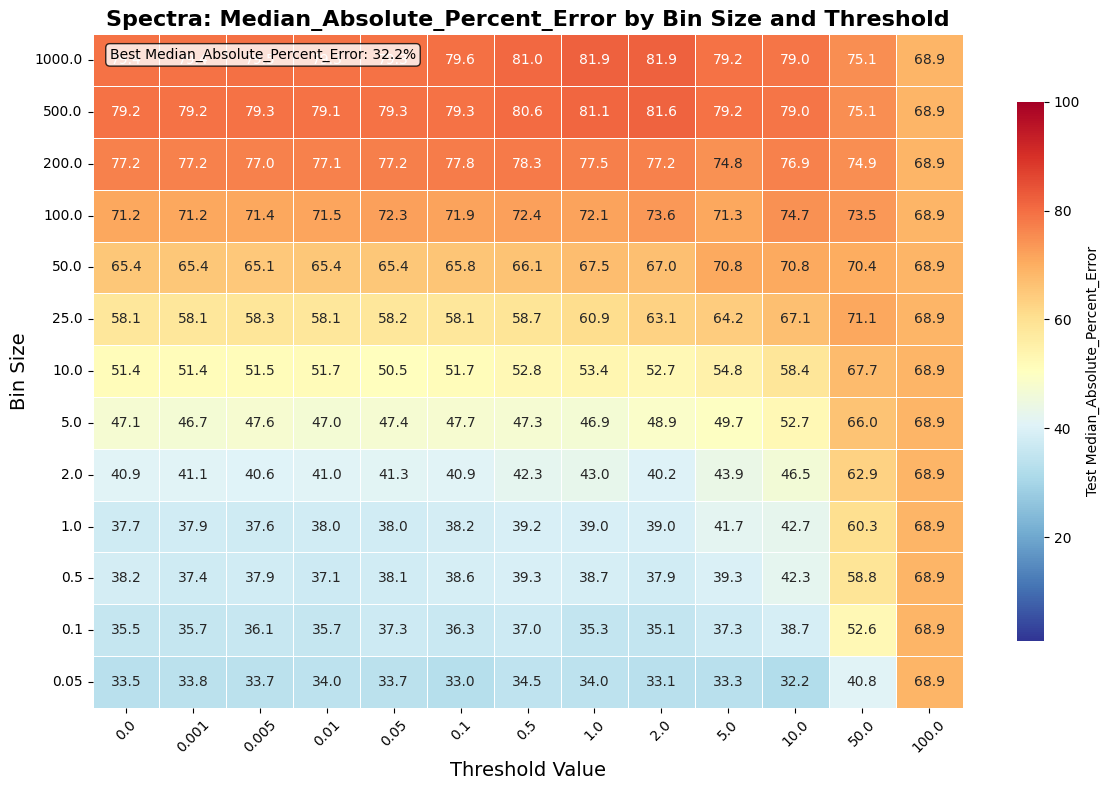

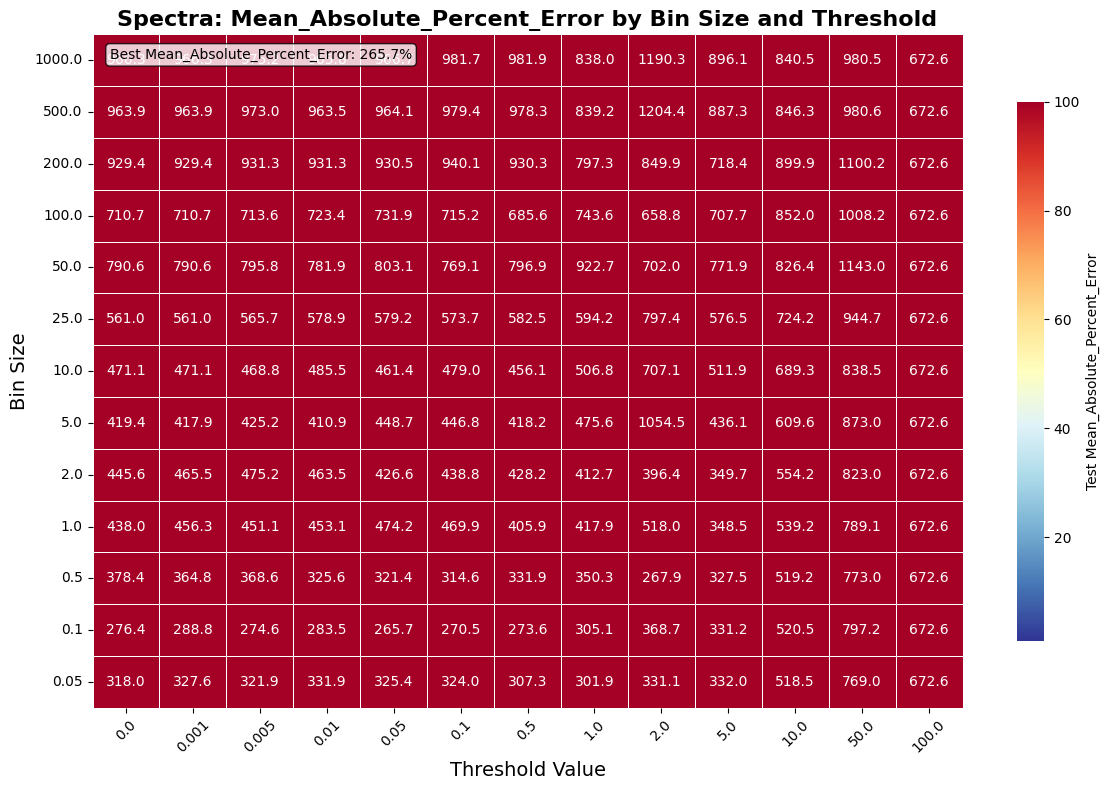

In [14]:
# Create the actual heatmaps for visualization
# First, let's extract bin size and threshold from the dataset names and add to results
def parse_dataset_name(dataset_name):
    """Extract bin size and threshold from dataset name"""
    # Handle thresh_zero case (no threshold)
    if 'thresh_zero' in dataset_name:
        # Extract bin size
        bin_part = dataset_name.split('_thresh_zero')[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        threshold = 0.0
    else:
        # Extract bin size and threshold
        parts = dataset_name.split('_thresh')
        bin_part = parts[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        
        thresh_part = parts[1].split('_df_spectra')[0]
        threshold = float(thresh_part.replace('_', '.'))
    
    return bin_size, threshold

# Add bin_size and threshold columns to results DataFrames
for df_results in [df_r2_results, df_percent_error_results]:
    bin_sizes = []
    thresholds = []
    
    for dataset_name in df_results['Dataset']:
        bin_size, threshold = parse_dataset_name(dataset_name)
        bin_sizes.append(bin_size)
        thresholds.append(threshold)
    
    df_results['BinSize'] = bin_sizes
    df_results['Threshold'] = thresholds

# Check for and remove duplicates before creating pivot tables
print("Checking for duplicates in results...")
print(f"Original df_r2_results shape: {df_r2_results.shape}")

# Remove duplicates based on BinSize + Threshold combination (keep first occurrence)
df_r2_results = df_r2_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')
df_percent_error_results = df_percent_error_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')

print(f"After removing duplicates: {df_r2_results.shape}")

# Now create pivot tables 
r2_pivot = df_r2_results.pivot(index='BinSize', columns='Threshold', values='Test_R2') 
median_percent_error_pivot = df_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Test_Median_Percent_Error')
mean_percent_error_pivot = df_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Test_Mean_Percent_Error')

# List all expected thresholds
thresholds_subset = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
bins_subset = [0.05, 0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]

# Reindex pivot tables to show all columns, filling missing with NaN
r2_pivot = r2_pivot.reindex(columns=thresholds_subset, index=bins_subset)
median_percent_error_pivot = median_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)
mean_percent_error_pivot = mean_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)

# Also create individual larger heatmaps for better detail
def create_detailed_heatmap_spec(pivot_data, metric_name, cmap, figsize=(12, 8), vmin=None, vmax=None):
    """Create a detailed heatmap for a single metric"""
    plt.figure(figsize=figsize)
    
    # Create heatmap
    sns.heatmap(pivot_data, 
                annot=True, 
                fmt='.3f' if 'R²' in metric_name else '.1f', 
                cmap=cmap,
                square=False,
                linewidths=0.5,
                vmin=vmin,
                vmax=vmax,
                cbar_kws={'label': f'Test {metric_name}', 'shrink': 0.8})
    
    plt.title(f'Spectra: {metric_name} by Bin Size and Threshold', fontsize=16, fontweight='bold')
    plt.xlabel('Threshold Value', fontsize=14)
    plt.ylabel('Bin Size', fontsize=14)
    plt.gca().invert_yaxis()
    
    # Improve readability
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    # Add text annotation for best performance
    if 'R²' in metric_name:
        best_val = pivot_data.max().max()
        plt.text(0.02, 0.98, f'Best R²: {best_val:.4f}', 
                transform=plt.gca().transAxes, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                verticalalignment='top')
    else:
        best_val = pivot_data.min().min()
        plt.text(0.02, 0.98, f'Best {metric_name}: {best_val:.1f}%', 
                transform=plt.gca().transAxes, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                verticalalignment='top')
    
    plt.tight_layout()
    plt.savefig(f"/home/dlipsey/MITLincolnLabs/Figures/Spectra_{metric_name}_by_Bin_Size_and_Threshold")
    plt.show()

# Create detailed individual heatmaps
print("Creating detailed heatmaps...")

# create_detailed_heatmap_spec(r2_pivot, 'R²', 'RdYlBu')     
create_detailed_heatmap_spec(median_percent_error_pivot, 'Median_Absolute_Percent_Error', 'RdYlBu_r', vmin=1.0, vmax=100.0) 
create_detailed_heatmap_spec(mean_percent_error_pivot, 'Mean_Absolute_Percent_Error', 'RdYlBu_r', vmin=1.0, vmax=100.0)

# ChemNet RF and Heatmap

## ChemNet RF

In [15]:
import os
import gc
import pickle

# Load ChemNet datasets folder path
chemnet_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/chemnet_grid_search_dataframes"

# Get all .pkl files in the folder
chemnet_pkl_files = [f for f in os.listdir(chemnet_folder) if f.endswith('.pkl')]
chemnet_dataset_names = [f.replace('.pkl', '') for f in chemnet_pkl_files]

print(f"Found {len(chemnet_dataset_names)} ChemNet datasets to process")

# Verify we have the right count
chemnet_thresh0_datasets = [name for name in chemnet_dataset_names if 'thresh_zero' in name]
chemnet_thresholded_datasets = [name for name in chemnet_dataset_names if 'thresh_zero' not in name]

print(f"  - ChemNet datasets with thresh0 (no threshold): {len(chemnet_thresh0_datasets)}")
print(f"  - ChemNet datasets with thresholds applied: {len(chemnet_thresholded_datasets)}")

# Initialize storage for ChemNet results
chemnet_results_r2 = []
chemnet_results_percent_error = []

# Dictionary to store individual errors for histogram analysis
saved_chemnet_errors = {}

# Process ChemNet datasets ONE AT A TIME (memory efficient)
for i, dataset_name in enumerate(sorted(chemnet_dataset_names), 1):
    print(f"Processing {i}/{len(chemnet_dataset_names)}: {dataset_name}")
    
    try:
        # Load only the current ChemNet dataset
        file_path = os.path.join(chemnet_folder, f"{dataset_name}.pkl")
        df = pd.read_pickle(file_path)
        
        # Prepare features and target (embedding columns are the features)
        feature_cols = [col for col in df.columns if col.startswith('emb_')]
        X = df[feature_cols]
        y = df['log_response']
        
        # Remove rows with NaN values
        valid_mask = ~(X.isna().any(axis=1) | y.isna())
        X_clean = X[valid_mask]
        y_clean = y[valid_mask]
        
        if len(X_clean) < 10:  # Skip if too few samples
            print(f"  Skipping {dataset_name}: Only {len(X_clean)} valid samples")
            continue
            
        # Split the data
        X_train, X_test, y_train, y_test = train_test_split(
            X_clean, y_clean, test_size=0.50, random_state=47
        )
        
        # Train Random Forest with limited CPU usage
        rf_chemnet = RandomForestRegressor(n_estimators=1, random_state=47, n_jobs=2)
        rf_chemnet.fit(X_train, y_train)

        # Make predictions
        y_train_pred = rf_chemnet.predict(X_train)
        y_test_pred = rf_chemnet.predict(X_test)
        
        # Calculate R² metrics
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        # Calculate absolute percent error (undo log transform first)
        y_train_true_response = np.exp(y_train)
        y_train_pred_response = np.exp(y_train_pred)
        y_test_true_response = np.exp(y_test)
        y_test_pred_response = np.exp(y_test_pred)
        
        # Calculate individual errors for test set
        individual_errors = np.abs((y_test_pred_response - y_test_true_response) / y_test_true_response) * 100
        
        # Save individual errors for histogram analysis
        saved_chemnet_errors[dataset_name] = individual_errors
        
        # Calculate median and mean absolute percent error
        train_median_percent_error = 100 * (np.median(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        test_median_percent_error = 100 * (np.median(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))
        train_mean_percent_error = 100 * (np.mean(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        test_mean_percent_error = 100 * (np.mean(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))

        # Store results
        chemnet_results_r2.append({
            'Dataset': dataset_name,
            'Train_R2': train_r2,
            'Test_R2': test_r2,
            'Samples': len(X_clean),
            'Features': len(feature_cols)
        })
        
        chemnet_results_percent_error.append({
            'Dataset': dataset_name,
            'Train_Median_Percent_Error': train_median_percent_error,
            'Test_Median_Percent_Error': test_median_percent_error,
            'Train_Mean_Percent_Error': train_mean_percent_error,
            'Test_Mean_Percent_Error': test_mean_percent_error,
            'Samples': len(X_clean),
            'Features': len(feature_cols)
        })
        
        print(f"Completed: Test R² = {test_r2:.4f}, Test Median % Error = {test_median_percent_error:.1f}%")
        
    except Exception as e:
        print(f"Error processing {dataset_name}: {str(e)}")
        continue
    
    finally:
        # Always clean up memory after each dataset
        if 'df' in locals():
            del df
        if 'X' in locals():
            del X, y, X_clean, y_clean
        if 'rf_chemnet' in locals():
            del rf_chemnet
        gc.collect()
        
        # Periodic deeper cleanup every 20 datasets
        if i % 20 == 0:
            print(f"  Deep cleanup after {i} datasets...")
            gc.collect()

# Convert results to DataFrames
df_chemnet_r2_results = pd.DataFrame(chemnet_results_r2)
df_chemnet_percent_error_results = pd.DataFrame(chemnet_results_percent_error)

print(f"\nCompleted! Processed {len(chemnet_results_r2)} ChemNet datasets successfully.")
print(f"Saved individual errors for {len(saved_chemnet_errors)} datasets")
print(f"Results stored in: df_chemnet_r2_results, df_chemnet_percent_error_results")

# Display summary statistics
print("\n=== CHEMNET SUMMARY STATISTICS ===")
print("Test R² Statistics:")
print(df_chemnet_r2_results['Test_R2'].describe())

print("\nTest Median Percent Error Statistics:")
print(df_chemnet_percent_error_results['Test_Median_Percent_Error'].describe())

print("\nTest Mean Percent Error Statistics:")
print(df_chemnet_percent_error_results['Test_Mean_Percent_Error'].describe())

# Show top 10 performing ChemNet datasets by Test R²
print("\n=== TOP 10 CHEMNET DATASETS BY TEST R² ===")
top_chemnet_r2 = df_chemnet_r2_results.nlargest(10, 'Test_R2')[['Dataset', 'Test_R2', 'Features']]
print(top_chemnet_r2.to_string(index=False))

# Show comparison between thresh0 (no threshold) and thresholded ChemNet datasets
print("\n=== CHEMNET THRESH0 vs THRESHOLDED COMPARISON ===")
chemnet_thresh0_results = df_chemnet_r2_results[df_chemnet_r2_results['Dataset'].str.contains('thresh_zero')]
chemnet_thresholded_results = df_chemnet_r2_results[~df_chemnet_r2_results['Dataset'].str.contains('thresh_zero')]

if len(chemnet_thresh0_results) > 0:
    print(f"ChemNet thresh0 datasets (no threshold) - Mean Test R²: {chemnet_thresh0_results['Test_R2'].mean():.4f}")
    print(f"Best ChemNet thresh0 dataset: {chemnet_thresh0_results.loc[chemnet_thresh0_results['Test_R2'].idxmax(), 'Dataset']} (R² = {chemnet_thresh0_results['Test_R2'].max():.4f})")

if len(chemnet_thresholded_results) > 0:
    print(f"ChemNet thresholded datasets - Mean Test R²: {chemnet_thresholded_results['Test_R2'].mean():.4f}")
    print(f"Best ChemNet thresholded dataset: {chemnet_thresholded_results.loc[chemnet_thresholded_results['Test_R2'].idxmax(), 'Dataset']} (R² = {chemnet_thresholded_results['Test_R2'].max():.4f})")

Found 157 ChemNet datasets to process
  - ChemNet datasets with thresh0 (no threshold): 12
  - ChemNet datasets with thresholds applied: 145
Processing 1/157: chemnet_emb_bin0_05_thresh0_001_df_spectra


Completed: Test R² = 0.6306, Test Median % Error = 0.0%
Processing 2/157: chemnet_emb_bin0_1_thresh0_001_df_spectra
Completed: Test R² = 0.5634, Test Median % Error = 0.0%
Processing 3/157: chemnet_emb_bin0_1_thresh0_005_df_spectra
Completed: Test R² = 0.5370, Test Median % Error = 0.0%
Processing 4/157: chemnet_emb_bin0_1_thresh0_01_df_spectra
Completed: Test R² = 0.5368, Test Median % Error = 0.0%
Processing 5/157: chemnet_emb_bin0_1_thresh0_05_df_spectra
Completed: Test R² = 0.4984, Test Median % Error = 0.0%
Processing 6/157: chemnet_emb_bin0_1_thresh0_1_df_spectra
Completed: Test R² = 0.5912, Test Median % Error = 0.0%
Processing 7/157: chemnet_emb_bin0_1_thresh0_5_df_spectra
Completed: Test R² = 0.6732, Test Median % Error = 0.0%
Processing 8/157: chemnet_emb_bin0_1_thresh100_df_spectra
Completed: Test R² = 1.0000, Test Median % Error = 0.0%
Processing 9/157: chemnet_emb_bin0_1_thresh10_df_spectra
Completed: Test R² = 0.5366, Test Median % Error = 0.0%
Processing 10/157: chemnet_

## ChemNet Heatmap

Checking for duplicates in ChemNet results...
Original df_chemnet_r2_results shape: (157, 7)
After removing duplicates: (157, 7)
Creating detailed ChemNet heatmaps...


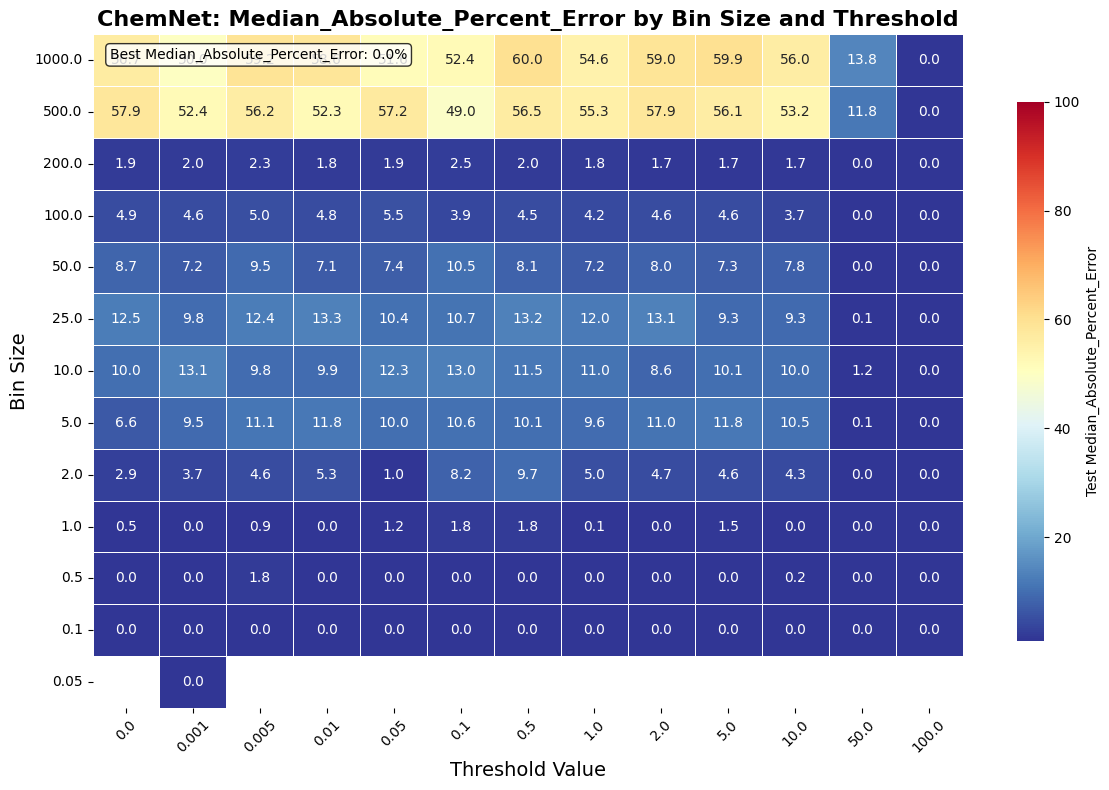

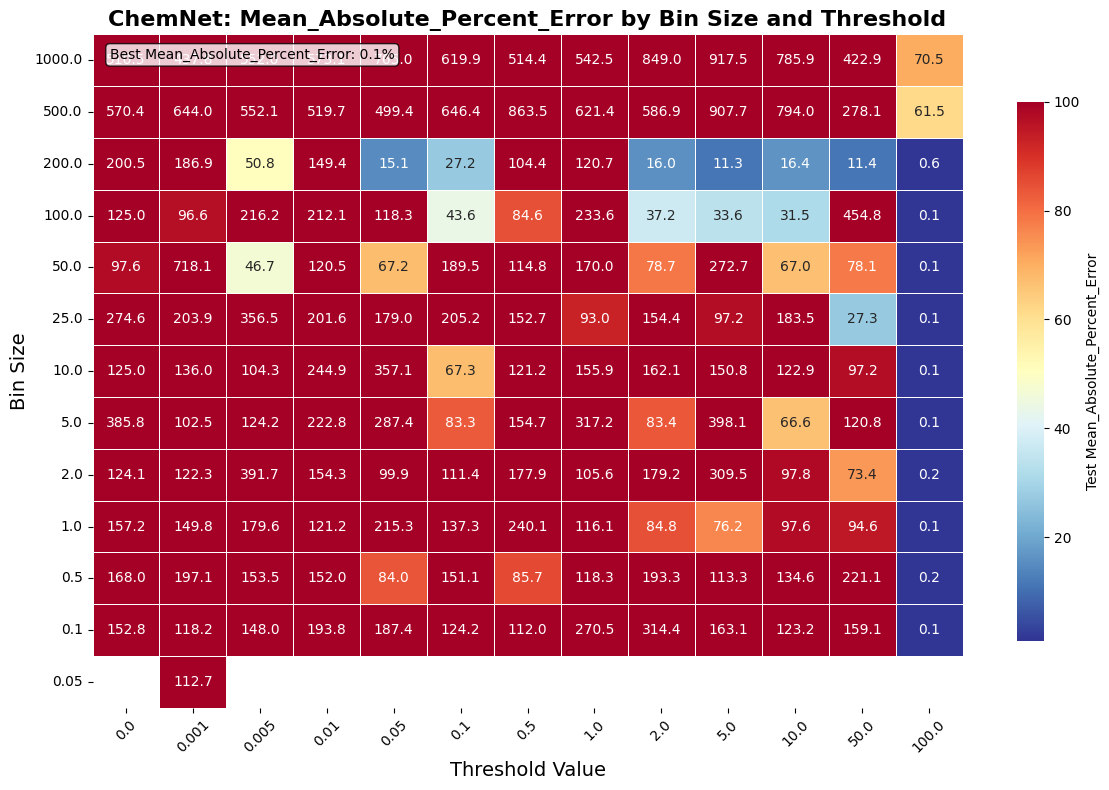

In [16]:
# Create the actual heatmaps for ChemNet visualization
# First, let's extract bin size and threshold from the ChemNet dataset names and add to results
def parse_chemnet_dataset_name(dataset_name):
    """Extract bin size and threshold from ChemNet dataset name"""
    # Remove 'chemnet_emb_' prefix
    name_part = dataset_name.replace('chemnet_emb_', '')
    
    # Handle thresh_zero case (no threshold)
    if 'thresh_zero' in name_part:
        # Extract bin size
        bin_part = name_part.split('_thresh_zero')[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        threshold = 0.0
    else:
        # Extract bin size and threshold
        parts = name_part.split('_thresh')
        bin_part = parts[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        
        thresh_part = parts[1].split('_df_spectra')[0]
        threshold = float(thresh_part.replace('_', '.'))
    
    return bin_size, threshold

# Add bin_size and threshold columns to ChemNet results DataFrames
for df_results in [df_chemnet_r2_results, df_chemnet_percent_error_results]:
    bin_sizes = []
    thresholds = []
    
    for dataset_name in df_results['Dataset']:
        bin_size, threshold = parse_chemnet_dataset_name(dataset_name)
        bin_sizes.append(bin_size)
        thresholds.append(threshold)
    
    df_results['BinSize'] = bin_sizes
    df_results['Threshold'] = thresholds

# Check for and remove duplicates before creating pivot tables
print("Checking for duplicates in ChemNet results...")
print(f"Original df_chemnet_r2_results shape: {df_chemnet_r2_results.shape}")

# Remove duplicates based on BinSize + Threshold combination (keep first occurrence)
df_chemnet_r2_results = df_chemnet_r2_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')
df_chemnet_percent_error_results = df_chemnet_percent_error_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')

print(f"After removing duplicates: {df_chemnet_r2_results.shape}")

# Now create pivot tables for ChemNet
chemnet_r2_pivot = df_chemnet_r2_results.pivot(index='BinSize', columns='Threshold', values='Test_R2') 
chemnet_median_percent_error_pivot = df_chemnet_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Test_Median_Percent_Error')
chemnet_mean_percent_error_pivot = df_chemnet_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Test_Mean_Percent_Error')

# List all expected thresholds
thresholds_subset = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
bins_subset = [0.05, 0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000] # 0.05, 0.1,

# Reindex pivot tables to show all columns, filling missing with NaN
chemnet_r2_pivot = chemnet_r2_pivot.reindex(columns=thresholds_subset, index=bins_subset)
chemnet_median_percent_error_pivot = chemnet_median_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)
chemnet_mean_percent_error_pivot = chemnet_mean_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)


# Also create individual larger heatmaps for ChemNet for better detail
def create_detailed_heatmap_chemnet(pivot_data, metric_name, cmap, figsize=(12, 8), vmin=None, vmax=None):
    """Create a detailed heatmap for a single ChemNet metric"""
    plt.figure(figsize=figsize)
    
    # Create heatmap
    sns.heatmap(pivot_data, 
                annot=True, 
                fmt='.3f' if 'R²' in metric_name else '.1f', 
                cmap=cmap,
                square=False,
                linewidths=0.5,
                vmin=vmin,
                vmax=vmax,
                cbar_kws={'label': f'Test {metric_name}', 'shrink': 0.8})
    
    plt.title(f'ChemNet: {metric_name} by Bin Size and Threshold', fontsize=16, fontweight='bold')
    plt.xlabel('Threshold Value', fontsize=14)
    plt.ylabel('Bin Size', fontsize=14)
    plt.gca().invert_yaxis()
    
    # Improve readability
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    # Add text annotation for best performance
    if 'R²' in metric_name:
        best_val = pivot_data.max().max()
        plt.text(0.02, 0.98, f'Best R²: {best_val:.4f}', 
                transform=plt.gca().transAxes, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                verticalalignment='top')
    else:
        best_val = pivot_data.min().min()
        plt.text(0.02, 0.98, f'Best {metric_name}: {best_val:.1f}%', 
                transform=plt.gca().transAxes, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                verticalalignment='top')
    
    plt.tight_layout()
    plt.savefig(f"/home/dlipsey/MITLincolnLabs/Figures/ChemNet_{metric_name}_by_Bin_Size_and_Threshold")

    plt.show()

# Create detailed individual ChemNet heatmaps
print("Creating detailed ChemNet heatmaps...")

# create_detailed_heatmap_chemnet(chemnet_r2_pivot, 'R²', 'RdYlBu')     
create_detailed_heatmap_chemnet(chemnet_median_percent_error_pivot, 'Median_Absolute_Percent_Error', 'RdYlBu_r', vmin=1.0, vmax=100.0) 
create_detailed_heatmap_chemnet(chemnet_mean_percent_error_pivot, 'Mean_Absolute_Percent_Error', 'RdYlBu_r', vmin=1.0, vmax=100.0)

In [ ]:
def create_chemnet_pca_plot(dataset_name, min_smiles_count=1, test_size=0.5, random_state=42):
    """
    Create a 2D PCA plot of ChemNet embeddings with train/test split and true embeddings
    
    Parameters:
    -----------
    dataset_name : str
        Name of the dataset file (without .pkl extension)
    min_smiles_count : int
        Minimum number of spectra required for a SMILES to be included
    test_size : float
        Proportion of data to use for testing (0.0 to 1.0)
    random_state : int
        Random seed for reproducible train/test splits
    """
    
    # Define paths
    chemnet_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/chemnet_grid_search_dataframes"
    true_embeddings_path = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_chemnet.parquet"
    
    # Load the ChemNet dataset
    dataset_path = os.path.join(chemnet_folder, f"{dataset_name}.pkl")
    if not os.path.exists(dataset_path):
        print(f"Error: Dataset {dataset_name}.pkl not found in {chemnet_folder}")
        return
    
    print(f"Loading dataset: {dataset_name}")
    df_chemnet = pd.read_pickle(dataset_path)
    
    # Load true embeddings
    print("Loading true ChemNet embeddings...")
    df_true = pd.read_parquet(true_embeddings_path)
    
    print(f"Original dataset shape: {df_chemnet.shape}")
    print(f"True embeddings shape: {df_true.shape}")
    
    # Filter by minimum SMILES count
    if min_smiles_count > 1:
        smiles_counts = df_chemnet['SMILES_spectra'].value_counts()
        valid_smiles = smiles_counts[smiles_counts >= min_smiles_count].index
        df_chemnet_filtered = df_chemnet[df_chemnet['SMILES_spectra'].isin(valid_smiles)].copy()
        print(f"After filtering (>={min_smiles_count} spectra per SMILES): {df_chemnet_filtered.shape}")
    else:
        df_chemnet_filtered = df_chemnet.copy()
    
    # Get embedding columns from the dataset
    emb_cols = [col for col in df_chemnet_filtered.columns if col.startswith('emb_')]
    print(f"Found {len(emb_cols)} embedding columns")
    
    if len(emb_cols) == 0:
        print("Error: No embedding columns found in dataset")
        return
    
    # Prepare features
    X = df_chemnet_filtered[emb_cols]
    smiles = df_chemnet_filtered['SMILES_spectra']
    
    # Remove rows with NaN values
    valid_mask = ~X.isna().any(axis=1)
    X_clean = X[valid_mask]
    smiles_clean = smiles[valid_mask]
    
    print(f"Clean data shape: {X_clean.shape}")
    
    if len(X_clean) < 10:
        print(f"Error: Only {len(X_clean)} valid samples - need at least 10")
        return
    
    # Create train/test split while keeping SMILES together
    unique_smiles = smiles_clean.unique()
    
    if test_size > 0:
        # Split by SMILES to ensure same SMILES don't appear in both train and test
        train_smiles, test_smiles = train_test_split(
            unique_smiles, test_size=test_size, random_state=random_state
        )
        
        train_mask = smiles_clean.isin(train_smiles)
        test_mask = smiles_clean.isin(test_smiles)
        
        X_train = X_clean[train_mask]
        X_test = X_clean[test_mask]
        smiles_train = smiles_clean[train_mask]
        smiles_test = smiles_clean[test_mask]
        
        print(f"Train set: {len(X_train)} samples, {len(train_smiles)} unique SMILES")
        print(f"Test set: {len(X_test)} samples, {len(test_smiles)} unique SMILES")
    else:
        # No split - use all data as training
        X_train = X_clean
        X_test = pd.DataFrame()
        smiles_train = smiles_clean
        smiles_test = pd.Series(dtype='object')
        train_mask = pd.Series([True] * len(X_clean), index=X_clean.index)
        test_mask = pd.Series([False] * len(X_clean), index=X_clean.index)
    
    # Get true embeddings for SMILES in our dataset
    # Match column names between datasets
    true_emb_cols = [col for col in df_true.columns if col.startswith('Embedding Float')]
    
    # Ensure we have the same number of embedding dimensions
    n_dims = min(len(emb_cols), len(true_emb_cols))
    X_train_matched = X_train.iloc[:, :n_dims]
    X_test_matched = X_test.iloc[:, :n_dims] if len(X_test) > 0 else pd.DataFrame()
    
    # Get true embeddings for SMILES that appear in our dataset
    dataset_smiles = set(smiles_clean.unique())
    df_true_matched = df_true[df_true['SMILES_spectra'].isin(dataset_smiles)].copy()
    
    if len(df_true_matched) > 0:
        X_true = df_true_matched[true_emb_cols[:n_dims]]
        smiles_true = df_true_matched['SMILES_spectra']
        print(f"True embeddings: {len(X_true)} samples for {len(smiles_true.unique())} unique SMILES")
    else:
        X_true = pd.DataFrame()
        smiles_true = pd.Series(dtype='object')
        print("Warning: No matching SMILES found in true embeddings")
    
    # Combine all data for PCA fitting
    X_all_list = [X_train_matched]
    if len(X_test_matched) > 0:
        X_all_list.append(X_test_matched)
    if len(X_true) > 0:
        X_all_list.append(X_true)
    
    X_all = pd.concat(X_all_list, ignore_index=True)
    
    # Perform PCA
    print("Performing PCA...")
    pca = PCA(n_components=2, random_state=random_state)
    X_all_pca = pca.fit_transform(X_all)
    
    # Split back the PCA results
    start_idx = 0
    end_idx = len(X_train_matched)
    X_train_pca = X_all_pca[start_idx:end_idx]
    start_idx = end_idx
    
    if len(X_test_matched) > 0:
        end_idx = start_idx + len(X_test_matched)
        X_test_pca = X_all_pca[start_idx:end_idx]
        start_idx = end_idx
    else:
        X_test_pca = np.array([]).reshape(0, 2)
    
    if len(X_true) > 0:
        X_true_pca = X_all_pca[start_idx:]
    else:
        X_true_pca = np.array([]).reshape(0, 2)
    
    # Create color mapping for SMILES
    all_smiles = pd.concat([smiles_train, smiles_test, smiles_true]).unique()
    n_smiles = len(all_smiles)
    
    if n_smiles <= 20:
        colors = cm.tab20(np.linspace(0, 1, 20))
    else:
        colors = cm.tab20(np.linspace(0, 1, 20))  # Cycle through tab20 colors
    
    color_map = {smiles: colors[i % 20] for i, smiles in enumerate(all_smiles)}
    
    # Create the plot
    plt.figure(figsize=(14, 10))
    
    # Plot training data as circles
    if len(X_train_pca) > 0:
        train_colors = [color_map[smiles] for smiles in smiles_train]
        plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], 
                   c=train_colors, marker='o', s=60, alpha=0.7, 
                   label='Training', edgecolors='black', linewidths=0.5)
    
    # Plot test data as x markers
    if len(X_test_pca) > 0:
        test_colors = [color_map[smiles] for smiles in smiles_test]
        plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], 
                   c=test_colors, marker='x', s=80, alpha=0.7, 
                   label='Testing', linewidths=2)
    
    # Plot true embeddings as squares
    if len(X_true_pca) > 0:
        true_colors = [color_map[smiles] for smiles in smiles_true]
        plt.scatter(X_true_pca[:, 0], X_true_pca[:, 1], 
                   c=true_colors, marker='s', s=80, alpha=0.8, 
                   label='True ChemNet', edgecolors='black', linewidths=1)
    
    # Customize plot
    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
    plt.title(f'2D PCA of ChemNet Embeddings: {dataset_name}\n'
              f'Min SMILES count: {min_smiles_count}, Total SMILES: {n_smiles}', 
              fontsize=14, fontweight='bold')
    
    # Add legend for markers
    plt.legend(loc='upper right', fontsize=11)
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Save the plot
    # plt.savefig(f"/home/dlipsey/MITLincolnLabs/Figures/ChemNet_PCA_{dataset_name}_minSMILES{min_smiles_count}.png", 
    #             dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary statistics
    print(f"\n=== SUMMARY ===")
    print(f"Dataset: {dataset_name}")
    print(f"Min SMILES count: {min_smiles_count}")
    print(f"Total unique SMILES: {n_smiles}")
    print(f"Training samples: {len(X_train_pca)} ({len(smiles_train.unique())} unique SMILES)")
    print(f"Test samples: {len(X_test_pca)} ({len(smiles_test.unique()) if len(smiles_test) > 0 else 0} unique SMILES)")
    print(f"True embedding samples: {len(X_true_pca)} ({len(smiles_true.unique()) if len(smiles_true) > 0 else 0} unique SMILES)")
    print(f"PCA Explained Variance: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")

# Example usage:
# List available datasets
chemnet_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/chemnet_grid_search_dataframes"
available_datasets = [f.replace('.pkl', '') for f in os.listdir(chemnet_folder) if f.endswith('.pkl')]
print("Available datasets:")
for i, dataset in enumerate(sorted(available_datasets)[:10]):  # Show first 10
    print(f"  {dataset}")
print(f"... and {len(available_datasets)-10} more")

# Create the plot - modify these parameters as needed
dataset_name = "chemnet_emb_bin0_1_thresh0_1_df_spectra"  
min_smiles_count = 2  # Modify this value to change minimum SMILES requirement
test_size = 0.3  # Modify this to change train/test split ratio

create_chemnet_pca_plot(dataset_name, min_smiles_count=min_smiles_count, test_size=test_size)

Available datasets:
  chemnet_emb_bin0_05_thresh0_001_df_spectra
  chemnet_emb_bin0_1_thresh0_001_df_spectra
  chemnet_emb_bin0_1_thresh0_005_df_spectra
  chemnet_emb_bin0_1_thresh0_01_df_spectra
  chemnet_emb_bin0_1_thresh0_05_df_spectra
  chemnet_emb_bin0_1_thresh0_1_df_spectra
  chemnet_emb_bin0_1_thresh0_5_df_spectra
  chemnet_emb_bin0_1_thresh100_df_spectra
  chemnet_emb_bin0_1_thresh10_df_spectra
  chemnet_emb_bin0_1_thresh1_df_spectra
... and 147 more
Error: Dataset chemnet_emb_bin0_1_thresh0_1_df3_QQpos_spectra.pkl not found in /home/dlipsey/MITLincolnLabs/MIT_LL_data/chemnet_grid_search_dataframes
